# 1. Data Loading - Binance

In [1]:
pip install python-binance


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /opt/anaconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import requests
import time
import os
from binance.client import Client
client = Client()  # или Client(api_key, api_secret)

# All dates are fixed manually — we do NOT use datetime.now().

START_DATE = "2021-01-01"
END_DATE = "2026-07-29"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Loading data from {START_DATE} to {END_DATE}")

Loading data from 2021-01-01 to 2026-07-29


In [3]:
# Binance data loader function

In [4]:
def get_binance_prices(symbol, start_date, end_date):
    """
    Download daily closing prices for one asset from Binance public API
    using the python-binance library.
    """
    klines = client.get_historical_klines(
        symbol,
        Client.KLINE_INTERVAL_1DAY,
        start_str=start_date,
        end_str=end_date,
    )

    df = pd.DataFrame(klines, columns=[
        "open_time", "open", "high", "low", "close", "volume",
        "close_time", "quote_asset_volume", "trades",
        "taker_buy_base", "taker_buy_quote", "ignore"
    ])

    series = pd.Series(
        data=df["close"].astype(float).values,
        index=pd.to_datetime(df["open_time"], unit="ms"),
        name=symbol,
    )
    return series

In [5]:
#Binance data loader function + saving 

In [6]:
assets = {
    "BTC-USD": "BTCUSDT",
    "ETH-USD": "ETHUSDT",
    "BNB-USD": "BNBUSDT",
    "SOL-USD": "SOLUSDT",
    "XRP-USD": "XRPUSDT",
    "DOGE-USD": "DOGEUSDT",
}

price_columns = {}

for asset_name, binance_symbol in assets.items():
    print(f"Downloading {asset_name}...")
    price_columns[asset_name] = get_binance_prices(binance_symbol, START_DATE, END_DATE)

# Combine all six price series into one table (rows = dates, columns = assets)
prices = pd.DataFrame(price_columns)

# Some assets may have slightly different daily timestamps (e.g. 00:00:00.001
# vs 00:00:00.000), so we normalize the index to just the date part.
prices.index = prices.index.normalize()

print(f"\nFinal table shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")

prices.tail()


Final table shape: (2036, 6)
Date range: 2021-01-01 to 2026-07-29


,BTC-USD,ETH-USD,BNB-USD,SOL-USD,XRP-USD,DOGE-USD
open_time,,,,,,
2026-07-25,64375.00,1874.89,568.94,74.52,1.0977,0.07172
2026-07-26,65399.99,1954.72,575.32,76.76,1.1131,0.07338
2026-07-27,63755.86,1892.53,566.28,74.20,1.0661,0.07038
2026-07-28,63915.00,1922.23,571.29,73.83,1.0690,0.07089
2026-07-29,63984.28,1910.72,571.99,73.68,1.0737,0.07014


In [7]:
prices.to_csv(f"{DATA_DIR}/prices.csv", index_label="date")
print("Saved to data/prices.csv")

Saved to data/prices.csv


# 2.Data Quality Checks 

In [8]:
# Check 1: are there any missing values?
print("Missing values per asset:")
print(prices.isna().sum())

Missing values per asset:
BTC-USD     0
ETH-USD     0
BNB-USD     0
SOL-USD     0
XRP-USD     0
DOGE-USD    0
dtype: int64


In [9]:
# Check 2: are there any gaps in the daily calendar?
# Crypto trades 24/7, so unlike stocks, we expect ZERO missing calendar days.
all_expected_days = pd.date_range(prices.index.min(), prices.index.max(), freq="D")
missing_days = all_expected_days.difference(prices.index)

print(f"Missing calendar days: {len(missing_days)}")
if len(missing_days) > 0:
    print(missing_days)

Missing calendar days: 0


In [10]:
# Check 3: any zero or negative prices? (would indicate a data error)
invalid_prices = (prices <= 0).sum()
print("Zero or negative prices per asset:")
print(invalid_prices)

Zero or negative prices per asset:
BTC-USD     0
ETH-USD     0
BNB-USD     0
SOL-USD     0
XRP-USD     0
DOGE-USD    0
dtype: int64


In [11]:
# Check 4: any duplicate dates in the index?
print(f"Duplicate dates: {prices.index.duplicated().sum()}")

Duplicate dates: 0


array([[<Axes: xlabel='open_time'>, <Axes: xlabel='open_time'>],
       [<Axes: xlabel='open_time'>, <Axes: xlabel='open_time'>],
       [<Axes: xlabel='open_time'>, <Axes: xlabel='open_time'>]],
      dtype=object)

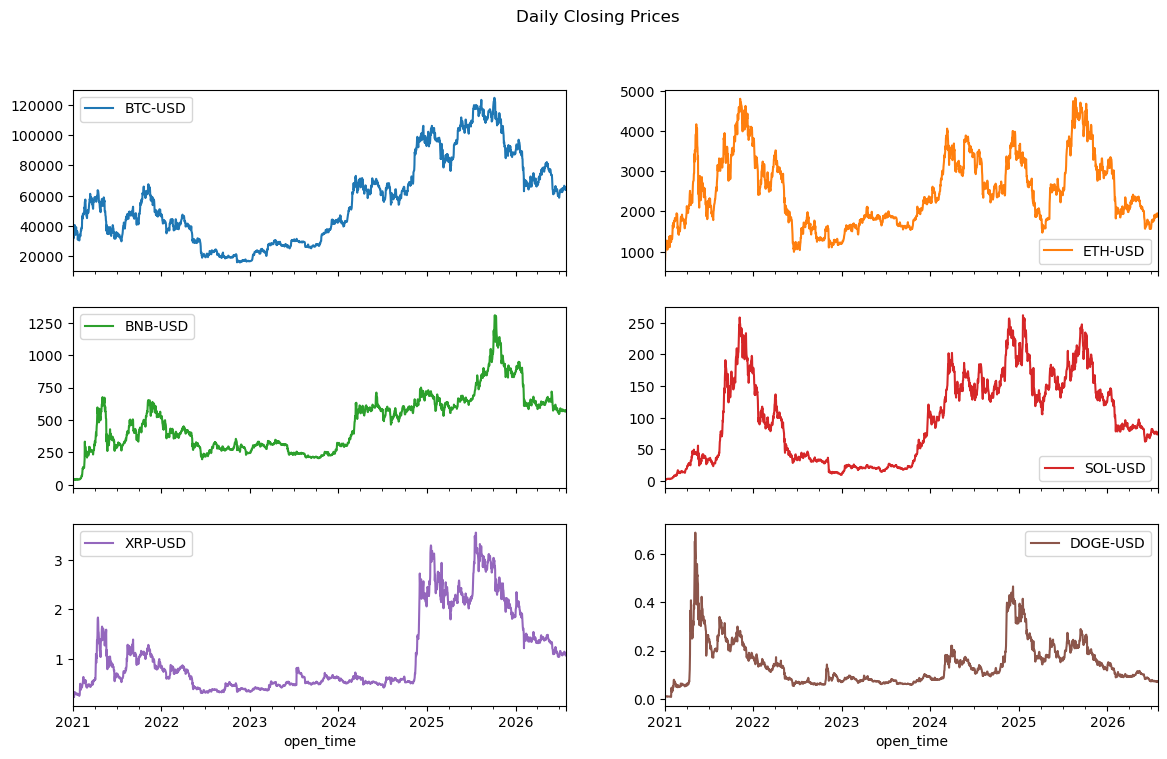

In [12]:
# Check 5: visual inspection — do the price charts look reasonable?
prices.plot(figsize=(14, 8), subplots=True, layout=(3, 2), title="Daily Closing Prices")

# No missing values or duplicate dates were found. All 6 assets had continuous trading history over the selected period. Visual inspection did not reveal any anomalies such as stale prices or gaps in the data.

# Log_returns

In [13]:
# Log returns are the standard input for risk metrics (VaR, volatility, etc.)
log_returns = np.log(prices / prices.shift(1)).dropna()

log_returns.to_csv(f"{DATA_DIR}/log_returns.csv", index_label="date")
print("Saved to data/log_returns.csv")

log_returns.describe()

Saved to data/log_returns.csv


,BTC-USD,ETH-USD,BNB-USD,SOL-USD,XRP-USD,DOGE-USD
count,2035.000000,2035.000000,2035.000000,2035.000000,2035.000000,2035.000000
mean,0.000383,0.000474,0.001335,0.001813,0.000741,0.001235
std,0.030091,0.040659,0.041302,0.057465,0.050255,0.070798
min,-0.166998,-0.324861,-0.416712,-0.549008,-0.407796,-0.485146
25%,-0.013363,-0.018757,-0.014527,-0.028453,-0.020320,-0.026265
50%,-0.000113,0.000736,0.001110,-0.000043,-0.000384,-0.001217
75%,0.014116,0.020058,0.015786,0.029393,0.019114,0.022199
max,0.178449,0.233750,0.532404,0.309672,0.548698,1.594144


# 3. Data Quality Check: resource comparison(Binance vs CoinGecko)

In [14]:
from dotenv import load_dotenv
load_dotenv()

COINGECKO_API_KEY = os.getenv("COINGECKO_API_KEY")

if COINGECKO_API_KEY is None:
    raise ValueError("COINGECKO_API_KEY not found. Add it to a .env file.")

In [15]:
def get_coingecko_prices(coin_id, days=365):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {"vs_currency": "usd", "days": days}
    headers = {"x-cg-demo-api-key": COINGECKO_API_KEY}

    response = requests.get(url, params=params, headers=headers, timeout=10)
    response.raise_for_status()

    raw_prices = response.json()["prices"]  # список [timestamp_ms, price]

    dates = [pd.to_datetime(p[0], unit="ms").normalize() for p in raw_prices]
    values = [p[1] for p in raw_prices]

    series = pd.Series(data=values, index=dates, name=coin_id)
    series = series.groupby(series.index).last()
    return series

In [16]:
coingecko_ids = {
    "BTC-USD": "bitcoin",
    "ETH-USD": "ethereum",
    "BNB-USD": "binancecoin",
    "SOL-USD": "solana",
    "XRP-USD": "ripple",
    "DOGE-USD": "dogecoin",
}

coingecko_columns = {}

for asset_name, coin_id in coingecko_ids.items():
    print(f"Downloading {asset_name} from CoinGecko...")
    coingecko_columns[asset_name] = get_coingecko_prices(coin_id)
    time.sleep(1.5)  # stay under the free-tier rate limit

coingecko_prices = pd.DataFrame(coingecko_columns)

coingecko_prices.to_csv(f"{DATA_DIR}/coingecko_prices.csv", index_label="date")
print("Saved to data/coingecko_prices.csv")

coingecko_prices.tail()

Saved to data/coingecko_prices.csv


,BTC-USD,ETH-USD,BNB-USD,SOL-USD,XRP-USD,DOGE-USD
2026-08-06,64574.312653,1906.363730,593.615049,74.006355,1.060789,0.069990
2026-08-07,64289.462650,1901.801377,592.509570,72.669807,1.034070,0.069128
2026-08-08,64872.600733,1912.159309,591.796305,73.589599,1.019922,0.069554
2026-08-09,64916.005480,1915.383699,600.516650,75.970498,1.039396,0.070386
2026-08-10,63791.696764,1868.453454,598.314458,75.611874,1.017442,0.069471


In [17]:
# We compare only BTC first, as a simple example
btc_binance = prices["BTC-USD"]
btc_coingecko = coingecko_prices["BTC-USD"]

comparison = pd.DataFrame({
    "binance": btc_binance,
    "coingecko": btc_coingecko,
}).dropna()

comparison["diff_pct"] = (comparison["binance"] - comparison["coingecko"]) / comparison["coingecko"] * 100

print("Comparing prices on the SAME calendar date:")
print(f"Max absolute difference: {comparison['diff_pct'].abs().max():.2f}%")

Comparing prices on the SAME calendar date:
Max absolute difference: 13.89%


In [18]:
# The difference above is often large (10-20%), which is suspicious for two
# major exchanges. The likely reason: Binance records the closing price at
# the END of a UTC day, while CoinGecko's timestamp corresponds to the
# START of a UTC day. So Binance's "close of day X" is really closer in
# time to CoinGecko's "price on day X+1", not "price on day X".

# We test this by shifting the CoinGecko series forward by one day before
# comparing, and check whether the difference gets smaller.
btc_coingecko_shifted = btc_coingecko.shift(-1)  # shift forward by 1 day

comparison_shifted = pd.DataFrame({
    "binance": btc_binance,
    "coingecko": btc_coingecko_shifted,
}).dropna()

comparison_shifted["diff_pct"] = (
    (comparison_shifted["binance"] - comparison_shifted["coingecko"])
    / comparison_shifted["coingecko"] * 100
)

print("Comparing prices AFTER shifting CoinGecko forward by 1 day:")
print(f"Max absolute difference: {comparison_shifted['diff_pct'].abs().max():.2f}%")

Comparing prices AFTER shifting CoinGecko forward by 1 day:
Max absolute difference: 3.76%


In [19]:
# If the shifted comparison gives a much smaller difference, our timing
# hypothesis is confirmed, and we apply the same 1-day shift to all assets
# for the final comparison table.
summary_rows = []

for asset_name in assets:
    binance_series = prices[asset_name]
    coingecko_series_shifted = coingecko_prices[asset_name].shift(-1)

    merged = pd.DataFrame({
        "binance": binance_series,
        "coingecko": coingecko_series_shifted,
    }).dropna()

    diff_pct = (merged["binance"] - merged["coingecko"]) / merged["coingecko"] * 100

    summary_rows.append({
        "asset": asset_name,
        "days_compared": len(merged),
        "mean_diff_pct": diff_pct.mean(),
        "max_abs_diff_pct": diff_pct.abs().max(),
    })

comparison_summary = pd.DataFrame(summary_rows).set_index("asset")
comparison_summary.to_csv(f"{DATA_DIR}/binance_vs_coingecko_summary.csv")

print(comparison_summary.round(2))

          days_compared  mean_diff_pct  max_abs_diff_pct
asset                                                   
BTC-USD             353           0.05              3.76
ETH-USD             353          -0.09              5.21
BNB-USD             353          -0.07              5.11
SOL-USD             353          -0.09              5.18
XRP-USD             353          -0.20              4.69
DOGE-USD            353          -0.09              2.51


# Conclusion

# Prices were sourced from Binance and cross-checked against CoinGecko(free tier limits history to 365 days, so verification covers only  the most recent year).

# A naive comparison on the same calendar date showed differences up to 13.89%, which was too large to be normal cross-exchange noise.  Investigation revealed that the two sources record the "daily price" at different points in time.

# After aligning timestamps with a 1-day shift, the mean difference  across all 6 assets dropped to within ±0.2%, with maximum single-day differences up to 5.21%. The residual maximum differences might reflect normal cross-exchange dispersion (CoinGecko aggregates prices across multiple exchanges, while this analysis uses Binance as a single reference exchange).

# Decision: documenting this as a known data limitation rather than investigating further, since:
# 1. Binance is used as the single primary source for all metrics in this project — CoinGecko is only a sanity check.
# 2. The affected window is a smaller window (just a year of CoinGecko data) while the overall is ~5.5 year analysis period.
# 3. Root-causing an external API's internal caching behavior is outside the scope of this project.